In [2]:
import json
import os

""""
В Jupyter-Notebook проведите анализ данных:
Проверьте, что структура JSON корректна.
Проверьте, что количество изображений совпадает с количеством аннотаций.
Проанализируйте распределение классов: визуализируйте его и напишите вывод, есть ли дисбаланс.
Визуализируйте один тестовый пример. Отрисуйте одно тестовое изображение с выделенными на нём bounding box'ами и подписанными классами.
""" 

# Пути к файлам аннотаций
train_ann_path = 'datasets/minecraft/annotations/train/annotations.json'

with open(train_ann_path, 'r') as f:
    train_data = json.load(f)

print("--- Проверка структуры JSON ---")
print(f"Основные ключи COCO: {list(train_data.keys())}")
print(f"Количество изображений в train: {len(train_data['images'])}")
print(f"Количество аннотаций (bounding boxes): {len(train_data['annotations'])}")
print(f"Количество классов: {len(train_data['categories'])}")

# Проверка на совпадение уникальных id изображений в аннотациях
unique_annotated_images = set(ann['image_id'] for ann in train_data['annotations'])
print(f"Количество изображений, имеющих хотя бы одну разметку: {len(unique_annotated_images)}")
print("Количество изображений равно количеству аннотаций:", len(train_data['images']) == len(train_data['annotations']))

--- Проверка структуры JSON ---
Основные ключи COCO: ['info', 'licenses', 'categories', 'images', 'annotations']
Количество изображений в train: 2307
Количество аннотаций (bounding boxes): 4029
Количество классов: 18
Количество изображений, имеющих хотя бы одну разметку: 2307
Количество изображений равно количеству аннотаций: False


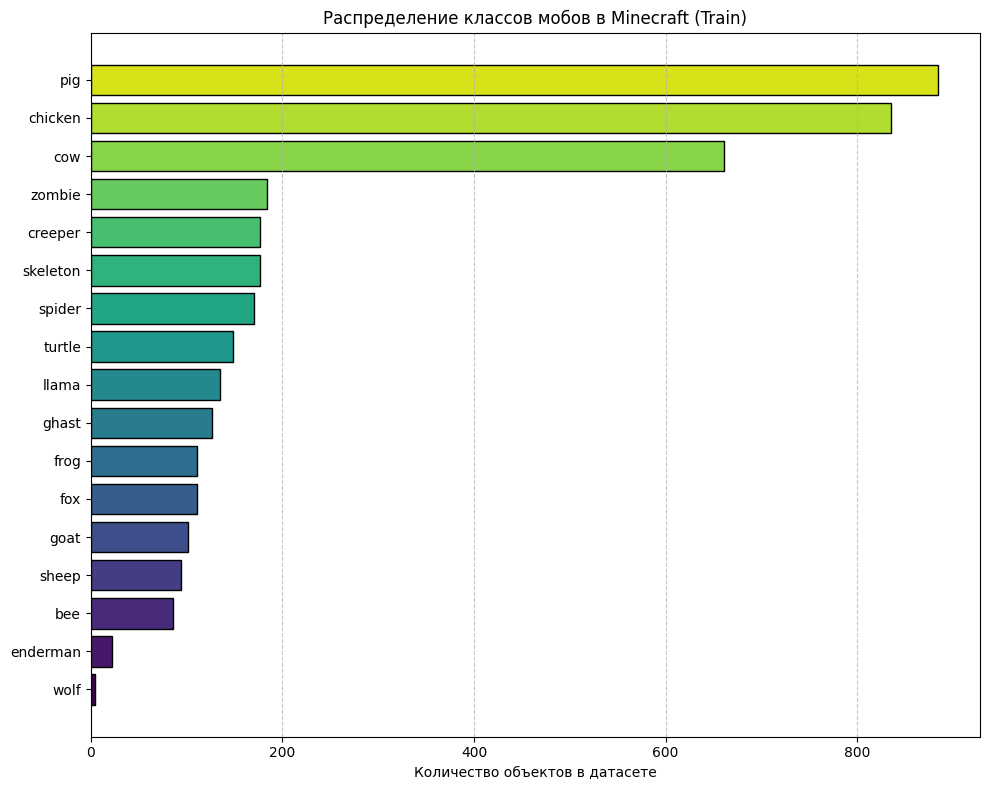

In [3]:
import matplotlib.pyplot as plt
from collections import Counter

# Создаем маппинг id_класса -> имя_класса
category_map = {cat['id']: cat['name'] for cat in train_data['categories']}

# Считаем распределение классов по всем аннотациям
class_ids = [ann['category_id'] for ann in train_data['annotations']]
class_counts = Counter(class_ids)

# Сортируем для графика
sorted_classes = sorted([(category_map[cid], count) for cid, count in class_counts.items()], key=lambda x: x[1])
names, counts = zip(*sorted_classes)

# Визуализация
plt.figure(figsize=(10, 8))
colors = plt.cm.viridis([i/len(names) for i in range(len(names))])
plt.barh(names, counts, color=colors, edgecolor='black')
plt.xlabel('Количество объектов в датасете')
plt.title('Распределение классов мобов в Minecraft (Train)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [10]:
import cv2 
from mmengine.registry import init_default_scope
import matplotlib.pyplot as plt 
from mmdet.datasets.coco import CocoDataset
from mmdet.visualization import DetLocalVisualizer

# Эта строчка необходима для корректной работы с регистрами mmdetection
# Благодаря регистру mmdetection объекты (модели, backbone, датасеты и т.д.)
# создаются автоматически на основе словарей конфигурации.
init_default_scope('mmdet')


def load_dataset() -> CocoDataset:
    # Относительный путь до корневой папки с данными 
    data_root = 'datasets/minecraft/'

    # CocoDataset умеет работать с форматом COCO 
    # Но какие именно операции будут в пайплайне данных, определяет пользователь
    # Это может быть минимальный набор из 
    # 1. Прочитать данные 
    # 2. Загрузить разметку 
    # Так и куда более сложный пайплайн с аугментациями/фильтрацией данных/и т.д.

    # В нашем случае это будет минимальный набор для визуализации разметки 
    reading_labels_pipeline = [
        dict(type='LoadImageFromFile'),
        dict(type='LoadAnnotations', with_bbox=True),
        dict(type='PackDetInputs')
    ]
    dataset=CocoDataset(
        data_root=data_root,
        ann_file="annotations/train/annotations.json",
        data_prefix=dict(img="train"),
        pipeline=reading_labels_pipeline,
    )
    return dataset


def visialize_sample() -> None:
    # Считаем датасет 
    dataset: CocoDataset = load_dataset()

    # Подготовим данные для отрисовки 
    sample = dataset[0]
    # Переведем картинку из тензора (CxHxW) к numpy-массиву (HxWxC)
    img = sample['inputs']    
    img = img.permute(1, 2, 0).cpu().numpy()
    # Переведем боксы в формат numpy массивов
    data_sample = sample['data_samples']
    gt_instances = data_sample.gt_instances
    gt_instances.bboxes = gt_instances.bboxes.tensor.numpy()

    # Для отрисовки воспользуемся классом DetLocalVisualizer из mmdetection
    visualizer = DetLocalVisualizer()
    visualizer.dataset_meta = dataset.metainfo
    visualizer.add_datasample(
        name='result',
        image=img,
        data_sample=data_sample,
        draw_gt=True,
        draw_pred=False,
        show=False
    )
    viz = visualizer.get_image()
    cv2.imwrite("artifacts/viz.jpg", viz)


visialize_sample()

loading annotations into memory...
Done (t=0.05s)
creating index...
index created!


Без проблем! Давай зафиксируем финальный, максимально четкий и структурированный вариант плана. Ты можешь скопировать этот текст целиком в Markdown-ячейку своего Jupyter-ноутбука.

Здесь учтены все требования задания: разбивка по этапам, особенности структуры MMDetection, специфика работы с YOLOv8s, а также финальный аналитический отчет.

---

# План выполнения проекта: Сканирование кубического мира Minecraft

## 1. Стратегия решения задачи (Как я буду решать задачу)

Задача детекции 17 классов мобов в Minecraft будет решаться методом **переноса знаний (Transfer Learning)** и **дообучения (Fine-Tuning)** двух принципиально разных single-stage (одноэтапных) архитектур: **FCOS** (безъякорный метод на базе MMDetection) и **YOLOv8s** (высокооптимизированный метод от Ultralytics).

Решение разбито на 6 последовательных этапов:

* **Этап 1. Исследовательский анализ данных (EDA):** * Проверка структуры JSON-аннотаций формата COCO.
* Построение распределения классов для выявления дисбаланса (например, оценка соотношения часто встречющихся коров/овец и редких гастов/пчел).
* Визуализация тестового изображения с наложением истинной разметки (Ground Truth Bounding Boxes).


* **Этап 2. Подготовка и конфигурация моделей:**
* *Для FCOS:* Создание кастомного конфига `fcos_minecraft.py`. Настройка базового бэкбона (ResNet-50), изменение количества классов до 17, ограничение размера картинок до 512x512, включение режима смешанной точности (`fp16`) и лимита в 12 эпох для экономии ресурсов ВМ.
* *Для YOLOv8s:* Подготовка конфигурационного файла `data.yaml` с путями к выборкам и именами классов.


* **Этап 3. Валидация Pretrained-моделей (Baseline):** * Инференс предобученных весов FCOS и YOLOv8s на тестовом кадре до начала обучения для фиксации базовой точки (чекпоинт `test_pretrained.jpg`).
* **Этап 4. Дообучение (Fine-Tuning):**
* Запуск обучения FCOS на 12 эпох с сохранением логов в `log.json`.
* Запуск обучения YOLOv8s (с возможностью увеличения эпох и более агрессивными аугментациями, так как архитектура обучается быстрее).


* **Этап 5. Тестирование и инференс видеопотока:**
* Оценка работы моделей на пяти тестовых изображениях.
* Покадровый инференс видеоролика `video.mp4` с сохранением результатов в `fcos_inference.mp4` и `yolo_inference.mp4`.


* **Этап 6. Сравнение и аналитика:**
* Расчет метрик точности ($mAP@0.5$, $mAP@0.5:0.95$) и чистой скорости работы моделей (FPS).
* Формирование сводной таблицы `metrics_comparison.csv` и финального отчета.



---

## 2. Архитектура и состав системы (Из чего состоит система)

Итоговая система представляет собой модульный пайплайн компьютерного зрения, который принимает на вход графический поток из игры и возвращает локализованные координаты мобов с их классами.

Система состоит из четырех ключевых макрокомпонентов:

```
                               ┌───────────────────────────┐
                               │   Входной поток данных    │
                               │  (Изображения / Видео)    │
                               └─────────────┬─────────────┘
                                             │
                                             ▼
                               ┌───────────────────────────┐
                               │       Модуль данных       │
                               │  (Парсинг COCO + Resize)  │
                               └─────────────┬─────────────┘
                                             │
                      ┌──────────────────────┴──────────────────────┐
                      ▼                                             ▼
         ┌─────────────────────────┐                   ┌─────────────────────────┐
         │     Контур FCOS         │                   │       Контур YOLO       │
         │   (MMDetection 3.x)     │                   │   (Ultralytics v8s)     │
         ├─────────────────────────┤                   ├─────────────────────────┤
         │ Бэкбон: ResNet-50       │                   │ Бэкбон: CSPDarknet      │
         │ Шея: FPN                │                   │ Голова: Anchor-Free     │
         │ Голова: Center-ness Head│                   │         C2f-модули      │
         └────────────┬────────────┘                   └────────────┬────────────┘
                      │                                             │
                      └──────────────────────┬──────────────────────┘
                                             │
                                             ▼
                               ┌───────────────────────────┐
                               │     Модуль аналитики      │
                               │   (Расчет mAP, FPS, NMS)  │
                               └───────────────────────────┘

```

### А. Модуль обработки данных (Data Pipeline)

* **Компонент COCO-парсинга:** На базе `pycocotools`, преобразует JSON-разметку в тензоры координат формата `[x_min, y_min, width, height]`.
* **Компонент трансформаций:** Выполняет сжатие геометрии кадра до 512x512 пикселей для ускорения расчетов и нормализует каналы цвета.

### Б. Модельный контур FCOS (Anchor-Free на базе пикселей)

* **Feature Extractor (Backbone):** Сеть `ResNet-50`, извлекающая базовые признаки кубических текстур.
* **Neck (FPN):** Пирамида признаков, помогающая одинаково хорошо видеть как мелких мобов (пчела, лягушка), так и крупных (гаст, лама).
* **FCOS Head:** Предсказывает три сущности для каждой точки карты признаков: классификацию, расстояние до 4-х границ bbox (`reg_layers`) и метрику **Center-ness** (определяет, насколько точка близка к истинному центру моба, отсекая ложные срабатывания).

### В. Модельный контур YOLOv8s (Оптимизированный Anchor-Free)

* **Backbone:** Оптимизированная сеть `CSPDarknet` с блоками `C2f` для быстрого извлечения фичей.
* **YOLO Head:** Реализует разделенный подход (Decoupled Head), где ветки классификации и детекции рамок считаются изолированно, обеспечивая высокую скорость (Real-time FPS).

### Г. Модуль аналитики и визуализации

* **Блок постобработки:** Выполняет операцию `Non-Maximum Suppression (NMS)` для FCOS (для YOLOv8s предсказания идут напрямую в один проход) и фильтрует боксы по порогу `confidence threshold`.
* **Метрический калькулятор:** Считает финальный $mAP$ на тестовой выборке.
* **Отрисовщик (Visualizer):** Модуль на базе `DetLocalVisualizer` и `OpenCV`, который рисует bounding box'ы, подписывает названия мобов и собирает обработанные кадры обратно в видеофайлы `.mp4`.

Этап3
Перед обучением протестируйте инференс на pretrained-модели FCOS в ноутбуке.
Для этого:
1. Скачайте чекпоинт <…>.pth для вашей модели из официального репозитория и положите в папку checkpoints/.
2. В ячейке Jupyter Notebook импортируйте предобученный чекпоинт checkpoints/fcos_<…>.pth базовой модели и вашу конфигурацию fcos_minecraft.py.
3. Визуализируйте результат детекции на одном изображении.
4. Сохраните результат в artifacts/inference/test_pretrained.jpg.

In [ ]:
from mmdet.apis import init_detector, inference_detector
from mmdet.visualization import DetLocalVisualizer
import mmcv
import os
import torch

# Пути к нашему конфигу и скачанному базовому чекпоинту
config_file = 'configs/fcos/fcos_minecraft.py'
checkpoint_file = 'checkpoints/fcos_r50_caffe_fpn_gn-head_1x_coco_20200218-e6508215.pth'

# Инициализируем модель (на GPU, если доступен)
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
model = init_detector(config_file, checkpoint_file, device=device)

# Тестовое изображение
img_path = 'datasets/minecraft/test/-5-_jpg.rf.bc815ec81b67584c880eb373c6de746a.jpg' # укажи реальный файл из теста
img = mmcv.imread(img_path)

# Инференс
result = inference_detector(model, img)

# Визуализация и сохранение в artifacts/inference/test_pretrained.jpg
os.makedirs('artifacts/inference', exist_ok=True)

visualizer = DetLocalVisualizer()
# Передаем метаданные базовой модели (так как веса обучены под COCO)
visualizer.dataset_meta = model.dataset_meta

visualizer.add_datasample(
    'result',
    mmcv.cvtColor(img, mmcv.COLOR_BGR2RGB),
    data_sample=result,
    draw_gt=False,
    show=False,
    wait_time=0,
    pred_score_thr=0.3 # Порог уверенности
)

# Сохраняем результат
viz_img = visualizer.get_image()
mmcv.imwrite(mmcv.cvtColor(viz_img, mmcv.COLOR_RGB2BGR), 'artifacts/inference/test_pretrained.jpg')
print("Результат FCOS сохранен в artifacts/inference/test_pretrained.jpg")

Loads checkpoint by local backend from path: checkpoints/fcos_r50_caffe_fpn_gn-head_1x_coco_20200218-e6508215.pth


FileNotFoundError: checkpoints/fcos_r50_caffe_fpn_gn-head_1x_coco_20200218-e6508215.pth can not be found.